In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
import yastn
from yastn.tn import mps

In [2]:
Nas = [(256, 0.125), (512, 0.0625), (512, 0.125)]
dEs = [-644.4618759299467 + 645.0617359295529, 2598.7026385786935 - 2598.116330318743, 1291.555420267803 - 1290.961527431732]
g = 1
m = 0.5
sg2 = 0.25
x0 = 1.5

In [3]:
probs_gs = {(N, a): np.load(f"./overlaps/probs_gs_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
# probs_gs[N, a] is a dictionary with keys (t, PP, D)  = (time, P of Gaussian, MPS bond dimension)

probs_R = {(N, a): np.load(f"./overlaps/probs_gauss_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
# probs_gs[N, a] is a dictionary with keys (t, PP, D, P)  = (time, P of Gaussian, MPS bond dimension, P of excited state)


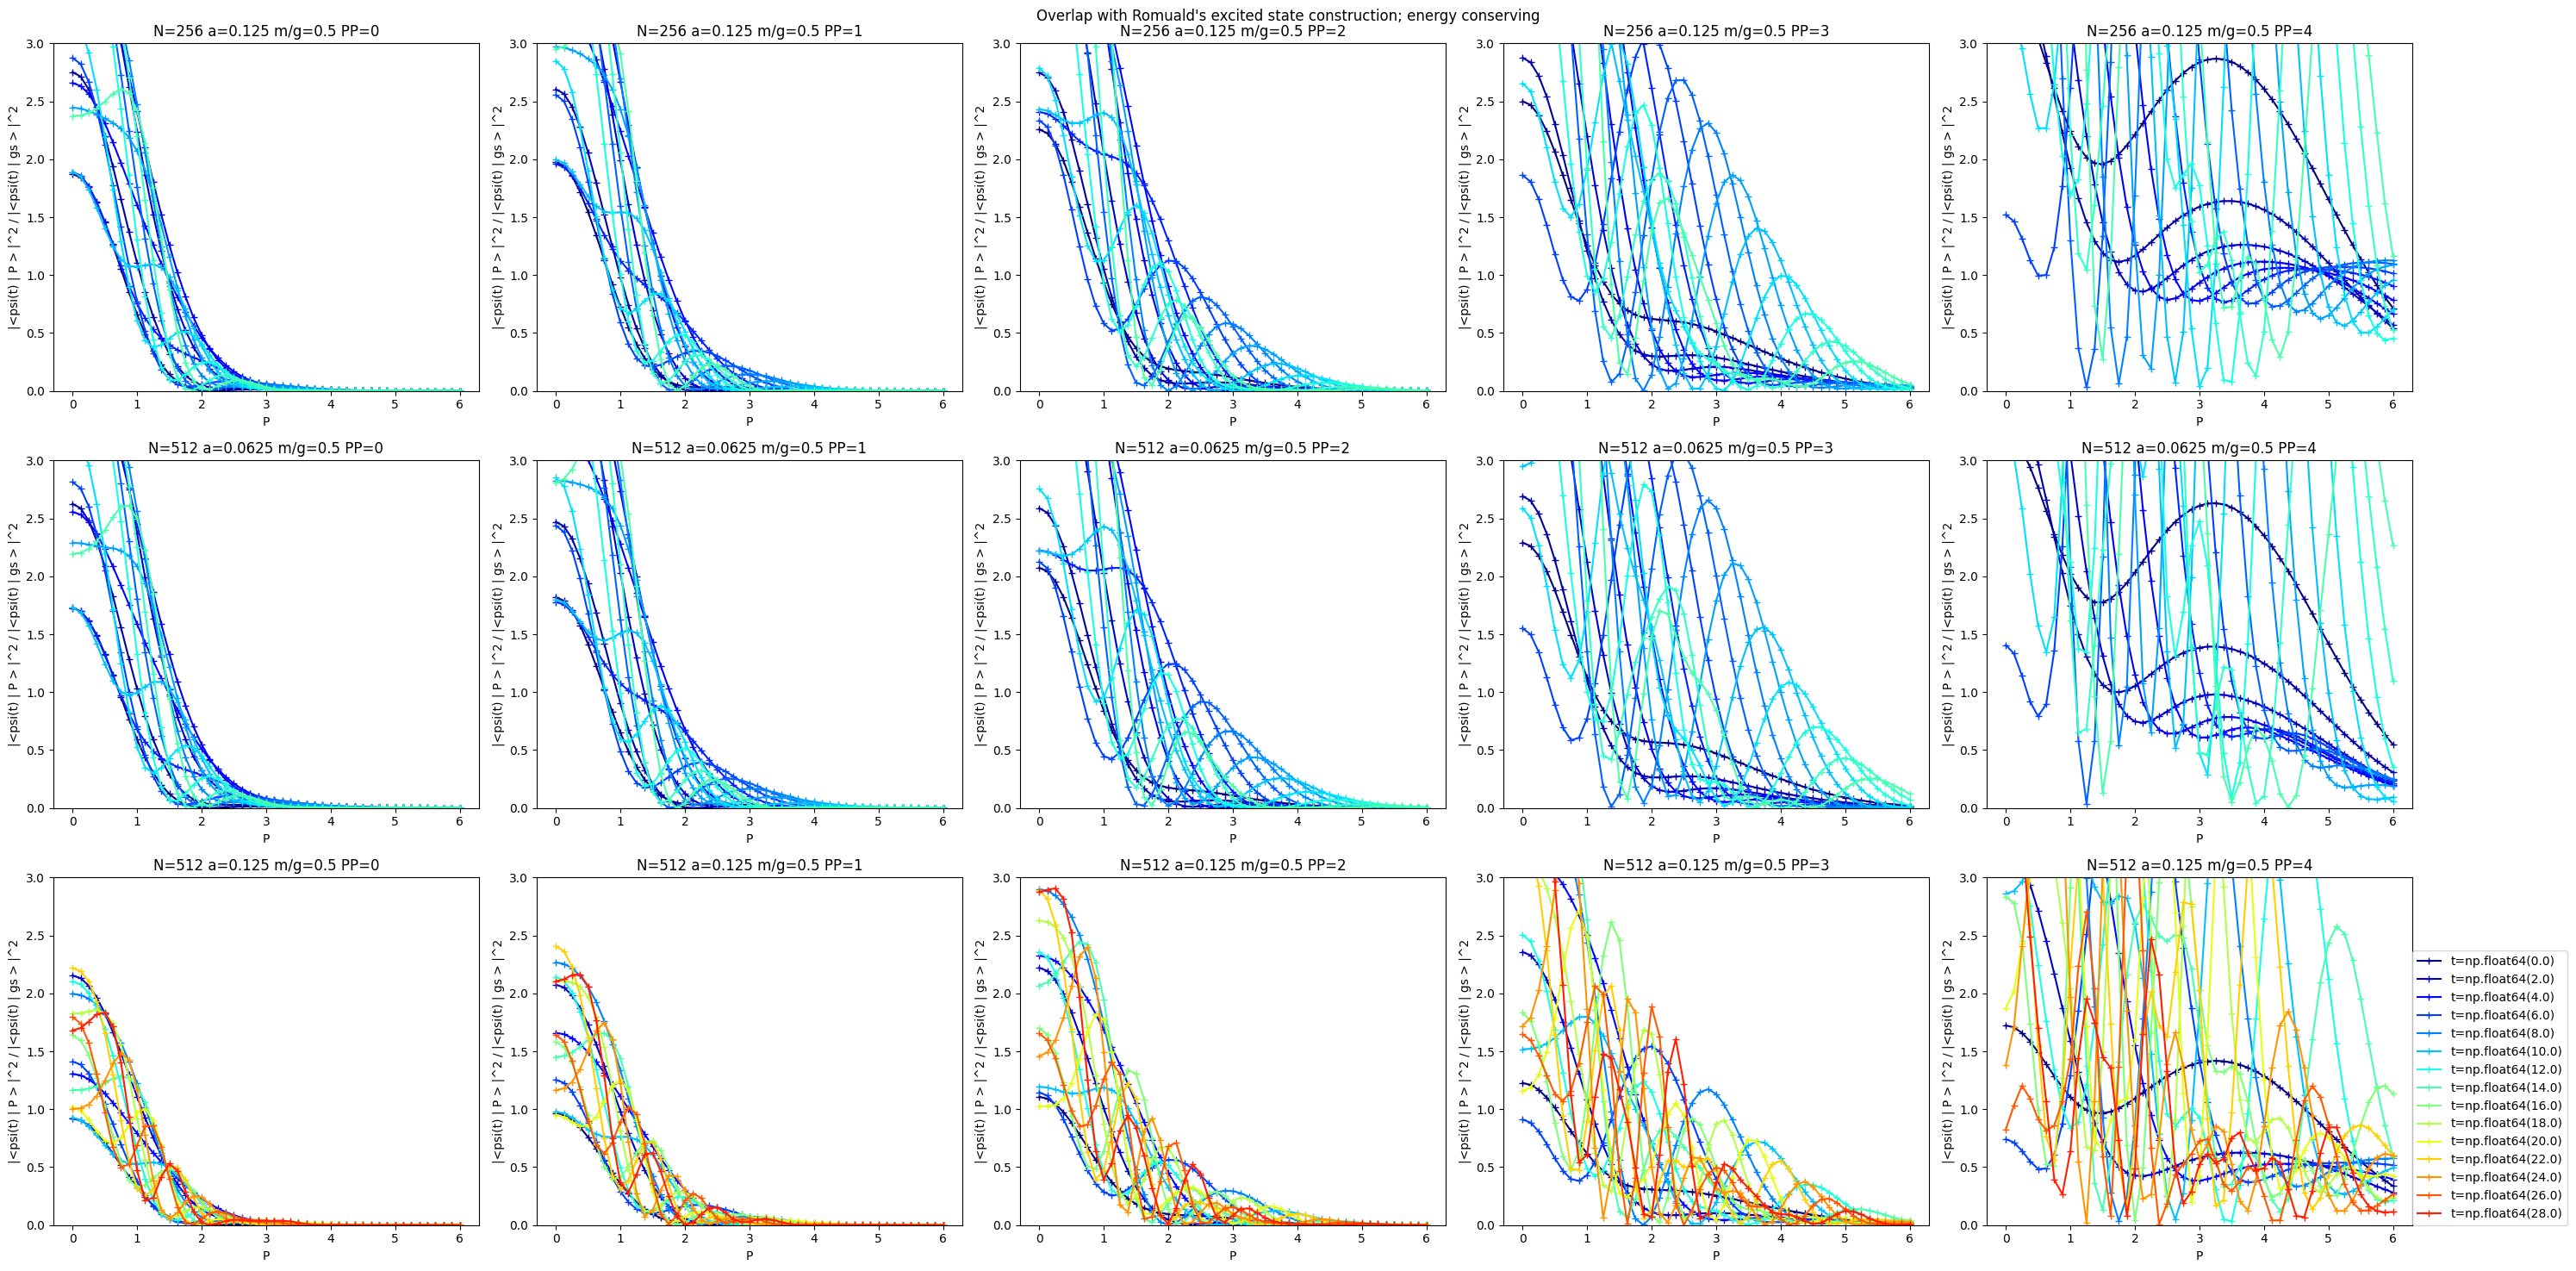

In [4]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]

PPs = np.linspace(0, 6, 49)

fig, axs = plt.subplots(len(Nas), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(Nas) * 5)
for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  ts = sorted(set(t for t, PP, D, P in probs_R[N, a]))
  Ds = sorted(set(D for t, PP, D, P in probs_R[N, a]))
  Ds = [512]
  #
  for jj, PP in enumerate(Ps):
      for D in Ds:
        for t in ts[:-2]:
          pr = [probs_R[N, a][t, PP, D, P] / probs_gs[N, a][t, PP, D] for P in PPs]
          sym = '-+' if D == Ds[0] else '-o'
          line, = axs[ii, jj].plot(PPs, pr, sym, color = cm(t / 32))
          if D == Ds[0]:
            line.set_label(f"{t=}")
      axs[ii,jj].set_xlabel('P')
      axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
      #axs[ii,jj].set_xlim([0, 2])
      axs[ii,jj].set_title(f"{N=} {a=} {m/g=} {PP=}")
      axs[ii,jj].set_ylim([0, 3])

axs[-1, -1].legend(loc=(1, 0))
fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [5]:
dd = {}
for N, a in Nas:
    dd[N, a] = np.load(f"./overlaps/Eng_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()

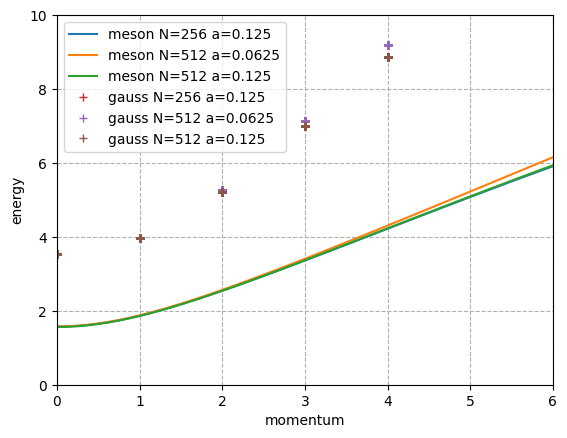

In [6]:
for N, a in Nas:
    k = np.array(list(dd[N, a]["E_P"].keys()))
    v = np.array(list(dd[N, a]["E_P"].values()))
    plt.plot(k, v - dd[N, a]["Egs"], '-', label=f"meson {N=} {a=}")
plt.ylim(0, 6)
plt.xlabel('momentum')
plt.ylabel('energy')


for N, a in Nas:
    k = np.array(list(x[1] for x in dd[N, a]["E_t"].keys()))
    v = np.array(list(dd[N, a]["E_t"].values()))
    plt.plot(k, v - dd[N, a]["Egs"], '+', label=f"gauss {N=} {a=}")
plt.ylim(0, 10)
plt.xlim(0, 6)
plt.grid(linestyle='--')

plt.legend()


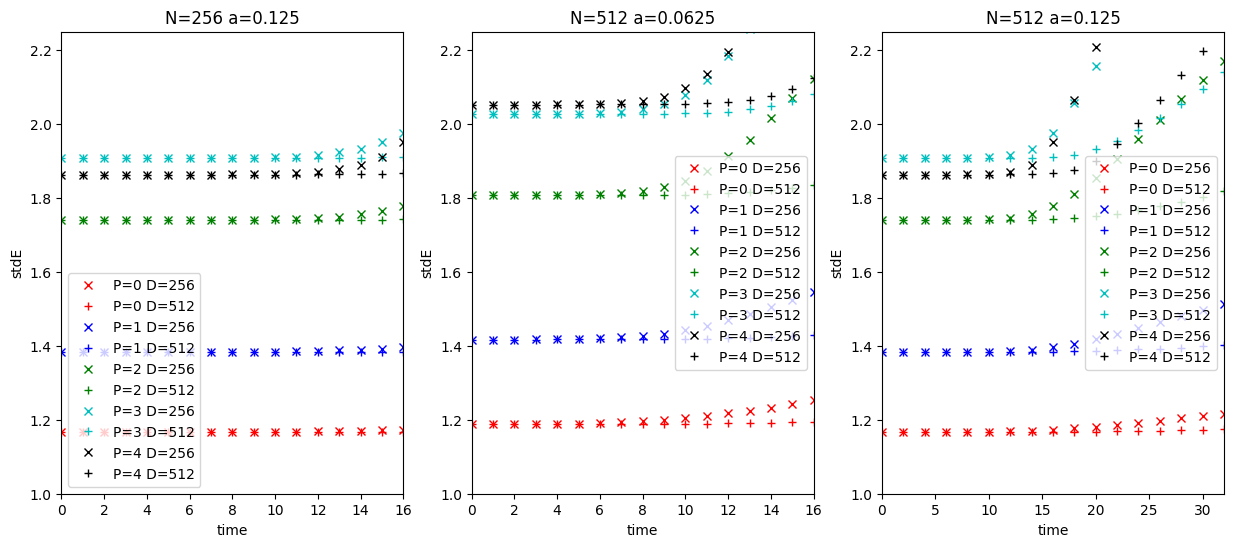

In [7]:
fig, axs = plt.subplots(1, len(Nas), squeeze=False)
fig.set_size_inches(len(Nas) * 5, 6)

for ii, (N, a) in enumerate(Nas):
    for clr, P in zip('rbgck', Ps):
        for sym, D in zip('x+', [256, 512]):
            xx = {k[0]: v for k, v in dd[N, a]["stdE"].items() if k[1] == P and k[2] == D}
            xx = dict(sorted(xx.items()))
            k = np.array(list(xx.keys()))
            v = np.array(list(xx.values()))
            axs[0, ii].plot(k, v, sym, label=f"{P=} {D=}", color=clr)
    axs[0, ii].set_xlabel('time')
    axs[0, ii].set_ylabel('stdE')
    axs[0, ii].legend()
    axs[0, ii].set_title(f"{N=} {a=}")
    axs[0, ii].set_xlim(0, N * a / 2)
    axs[0, ii].set_ylim(1.0, 2.25)


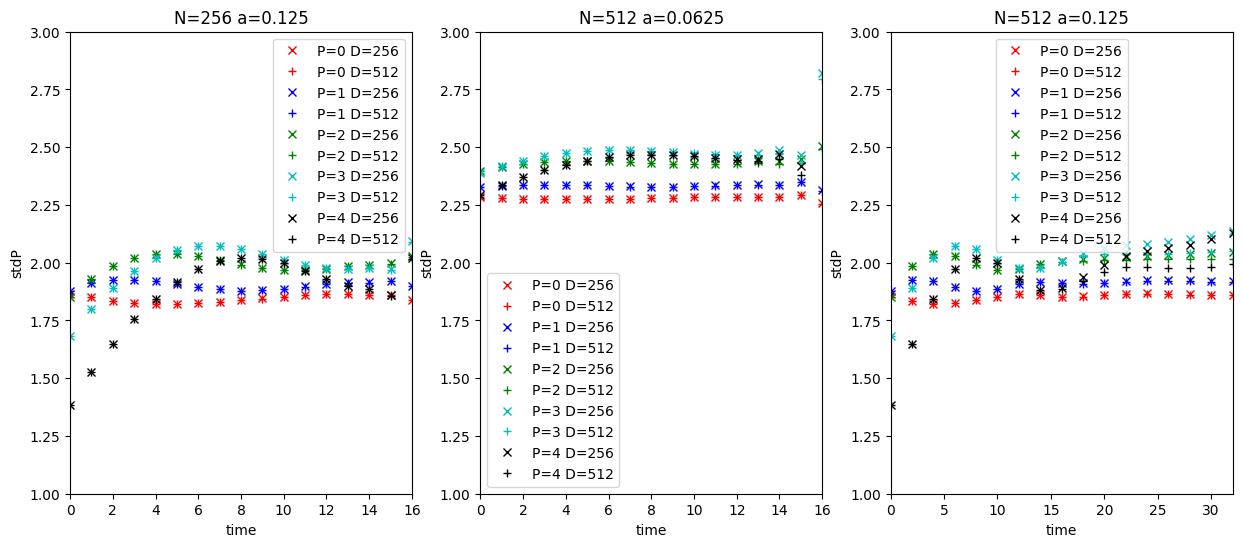

In [8]:
fig, axs = plt.subplots(1, len(Nas), squeeze=False)
fig.set_size_inches(len(Nas) * 5, 6)

for ii, (N, a) in enumerate(Nas):
    for clr, P in zip('rbgck', Ps):
        for sym, D in zip('x+', [256, 512]):
            xx = {k[0]: v for k, v in dd[N, a]["stdP"].items() if k[1] == P and k[2] == D}
            xx = dict(sorted(xx.items()))
            k = np.array(list(xx.keys()))
            v = np.array(list(xx.values()))
            axs[0, ii].plot(k, v, sym, label=f"{P=} {D=}", color=clr)
    axs[0, ii].set_xlabel('time')
    axs[0, ii].set_ylabel('stdP')
    axs[0, ii].legend()
    axs[0, ii].set_title(f"{N=} {a=}")
    axs[0, ii].set_xlim(0, N * a / 2)
    axs[0, ii].set_ylim(1.0, 3.0)


In [9]:
N, a = 256, 0.125
sg2s = [0.5, 0.25, 0.125, 0.0625]

probs_R2 = {sg2: np.load(f"./overlaps/probs_gauss_R_{m=}_{N=}_{a=}_{x0=:0.4f}_{sg2=:0.4f}.npy", allow_pickle=True).item() for sg2 in sg2s}
# probs_gs[N, a] is a dictionary with keys (t, PP, D, P)  = (time, P of Gaussian, MPS bond dimension, P of excited state)


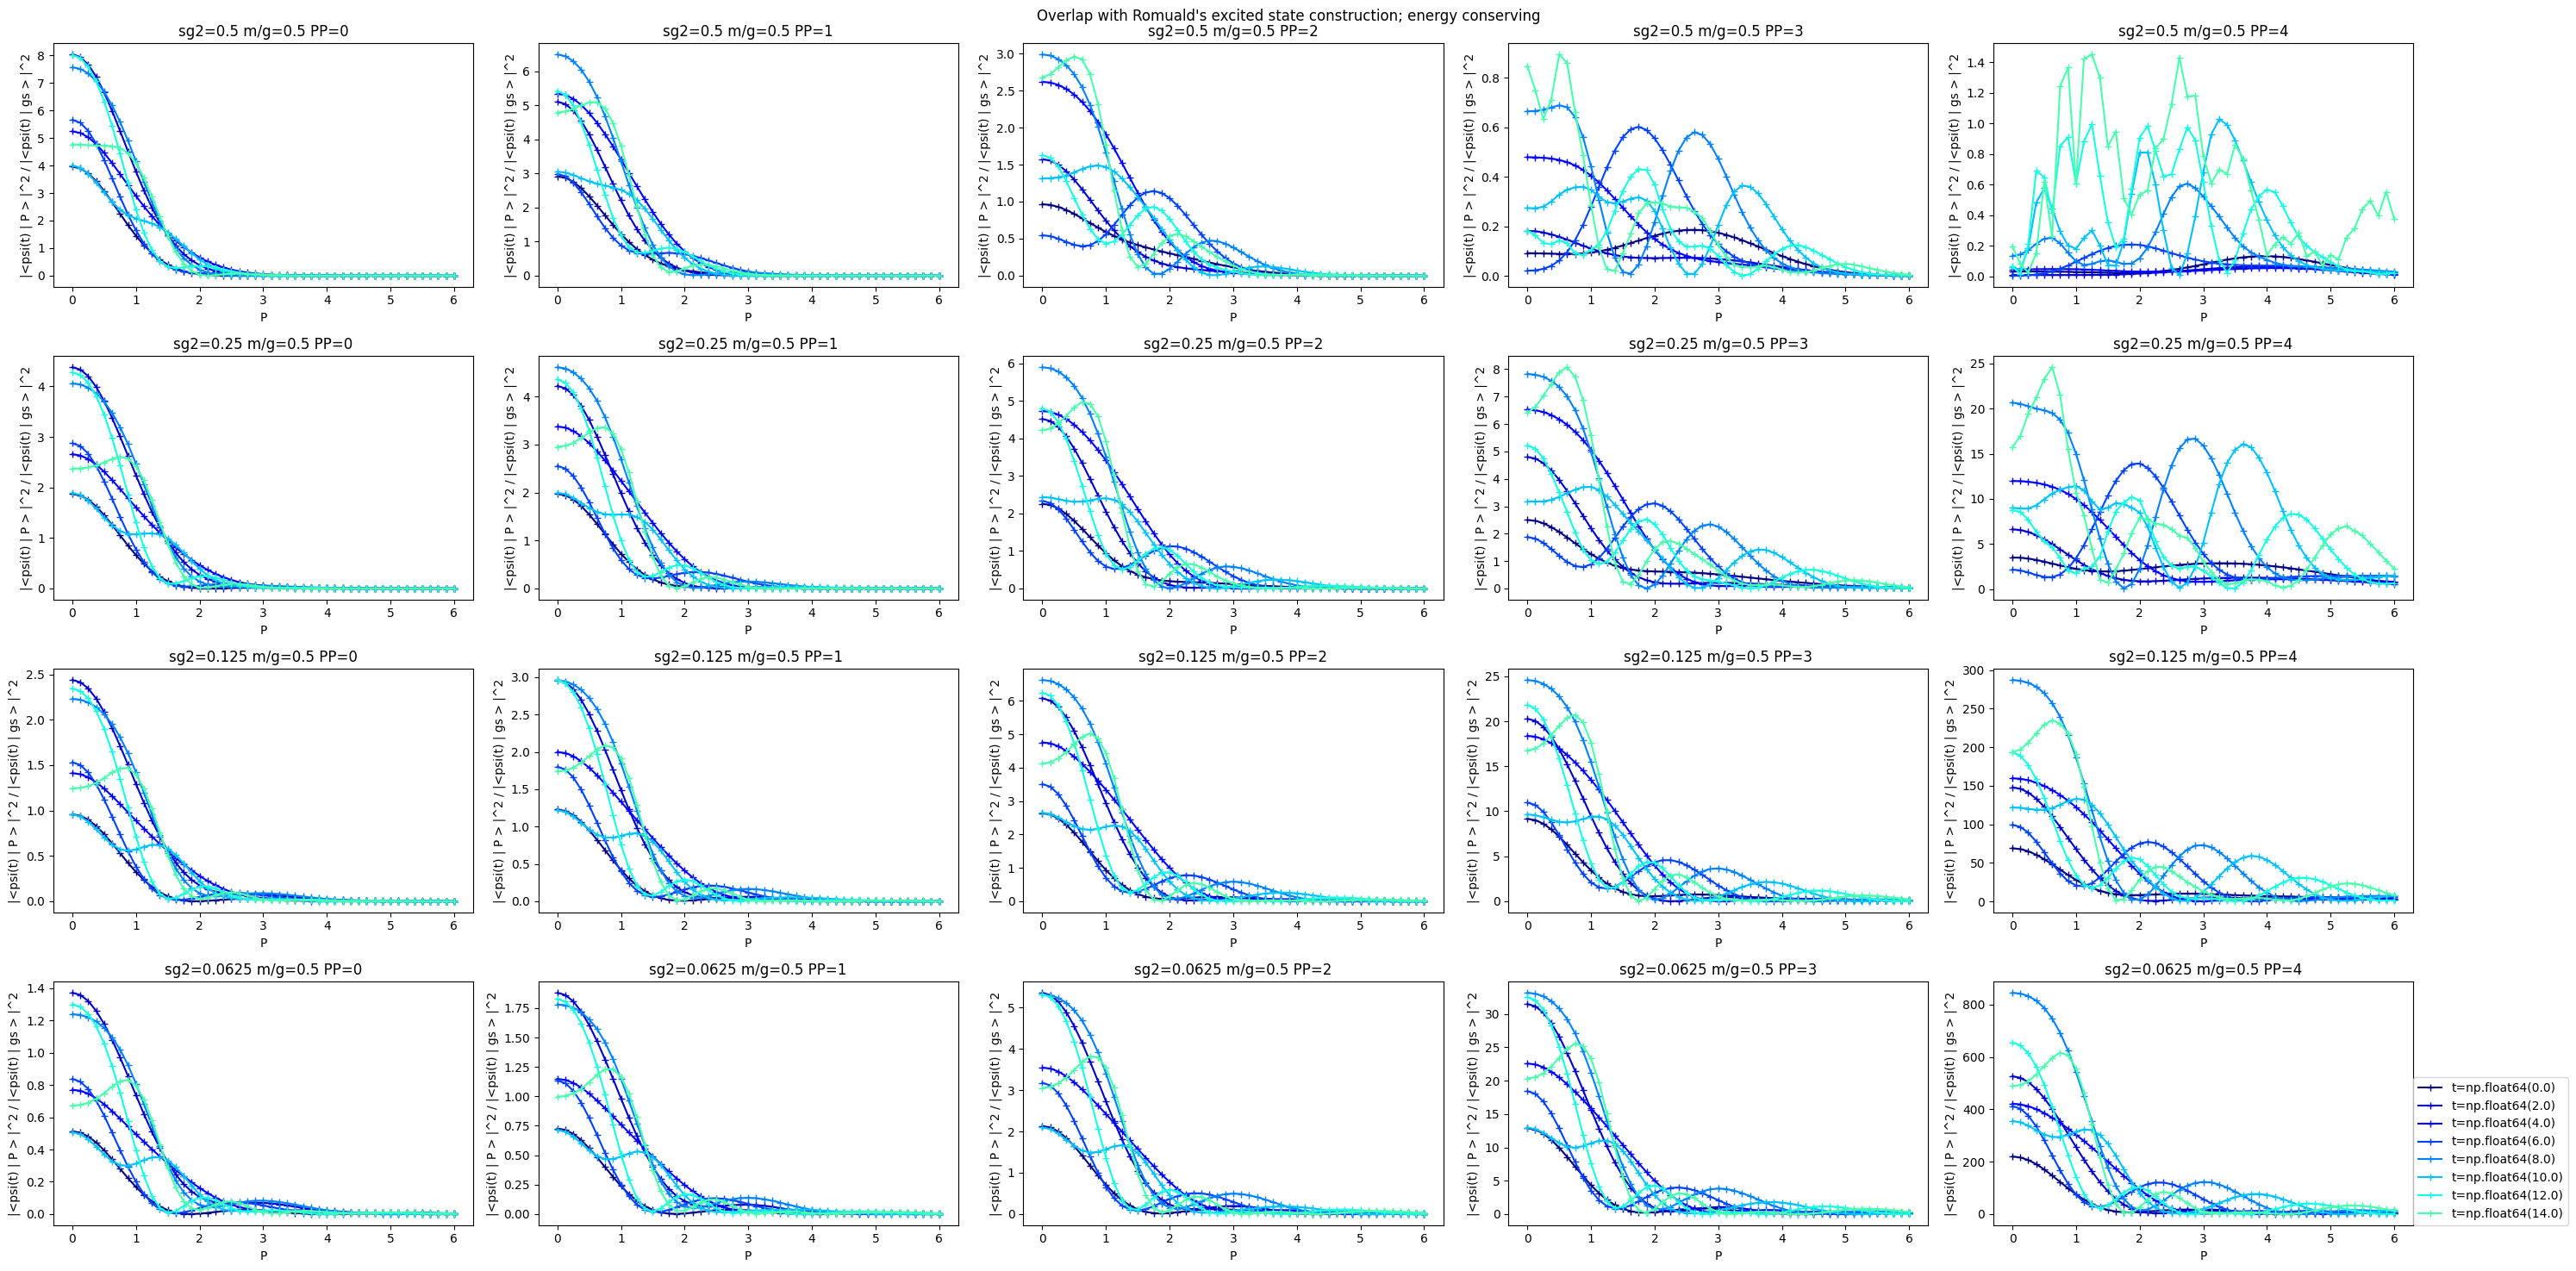

In [10]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]

PPs = np.linspace(0, 6, 49)

fig, axs = plt.subplots(len(sg2s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(Nas) * 5)
for ii, sg2 in enumerate(sg2s):
  #
  ts = sorted(set(t for t, PP, D, P in probs_R[N, a]))
  Ds = sorted(set(D for t, PP, D, P in probs_R[N, a]))
  Ds = [256]
  #
  for jj, PP in enumerate(Ps):
      for D in Ds:
        for t in ts[0:-2:2]:
          pr = [probs_R2[sg2][t, PP, D, P] / probs_gs[N, a][t, PP, D] for P in PPs]
          sym = '-+' if D == Ds[0] else '-o'
          line, = axs[ii, jj].plot(PPs, pr, sym, color = cm(t / 32))
          if D == Ds[0]:
            line.set_label(f"{t=}")
      axs[ii,jj].set_xlabel('P')
      axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
      #axs[ii,jj].set_xlim([0, 2])
      axs[ii,jj].set_title(f"{sg2=} {m/g=} {PP=}")
      #axs[ii,jj].set_ylim([0, 3])

axs[-1, -1].legend(loc=(1, 0))
fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [11]:
dd2 = {}
for sg2 in sg2s:
    dd2[sg2] = np.load(f"./overlaps/Eng_gauss_{m=}_{N=}_{a=}_{x0=:0.4f}_{sg2=:0.4f}.npy", allow_pickle=True).item()

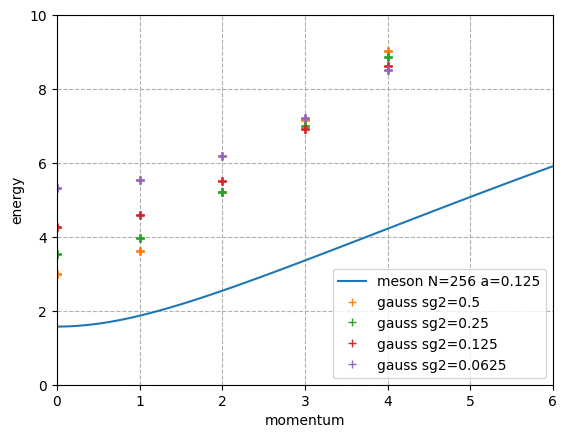

In [12]:
for sg2 in sg2s[:1]:
    k = np.array(list(dd2[sg2]["E_P"].keys()))
    v = np.array(list(dd2[sg2]["E_P"].values()))
    plt.plot(k, v - dd2[sg2]["Egs"], '-', label=f"meson {N=} {a=}")
plt.ylim(0, 6)
plt.xlabel('momentum')
plt.ylabel('energy')


for sg2 in sg2s:
    k = np.array(list(x[1] for x in dd2[sg2]["E_t"].keys()))
    v = np.array(list(dd2[sg2]["E_t"].values()))
    plt.plot(k, v - dd2[sg2]["Egs"], '+', label=f"gauss {sg2=}")
plt.ylim(0, 10)
plt.xlim(0, 6)
plt.grid(linestyle='--')

plt.legend()
